# GP-Bayesian Operator Inference: FitzHugh-Nagumo

**Workflow:**
1. Generate training data and fit POD basis
2. Fit GP hyperparameters
3. Compute operator via GP-derivative regression
4. Run Bayesian inference (SVI with AutoLowRankMultivariateNormal)
5. Evaluate and visualize results

## 1. Setup and Configuration

In [1]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import jax
import jax.numpy as jnp
import opinf
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist

from core import (
    generate_trajectory,
    JaxCompatibleModel,
    fit_gp_hyperparameters_mle,
    compute_gp_derivatives,
    build_bayesian_opinf_model,
    run_svi,
    generate_rom_predictions,
    plot_deterministic_rom_solves,
    plot_gp_fit,
    plot_operator_derivative_fit,
    plot_full_order_error,
    save_paper_figure,
    Plotter,
    run_diagnostics,
    diagnose_stability,
    DataScaler,
)
import config
from config import Basis, ReducedOrderModel
from fitz_plotter import FitzPlotter

numpyro.set_platform('cpu')
numpyro.set_host_device_count(4)

# Reproducibility
np.random.seed(42)
rng_key = jax.random.PRNGKey(42)

In [2]:
# === EXPERIMENT CONFIGURATION ===
OPERATORS = "cAHBN"       # OpInf operator structure (with inputs)
NUM_MODES = 3             # POD modes to retain
USE_LIFTING = False        # Use quadratic lifting basis (q1^2). False = plain POD.

# Data generation settings
TRAINING_SPAN = (0, 3.0)  # Subset of time domain for training
PREDICTION_SPAN = (0, 5.0) # Full time domain for ROM evaluation
NUM_SAMPLES = 450          # Number of training samples
NOISE_LEVEL = 0.01        # Noise level for training data
NUM_EVAL_POINTS = None     # Set to None for no densification
LS_BOUNDS = (0.01, 1.5)   # Lengthscale bounds for GP MLE (None for unconstrained)
IVP_METHOD = "Radau"   # ODE solver for stability testing (implicit for stiff FN system)

# Data scaling
USE_SCALED_DATA = False    # Standardize POD coefficients for GP fitting

# Inference settings
RUN_SVI = True
GUIDE = numpyro.infer.autoguide.AutoNormal
SVI_RANK = 5  # Rank for low-rank MVN guide covariance
VERBOSE = True             # Show progress bars (set False for papermill runs)

# Hyperparameters
GAMMA = 1e-1      # Operator prior scale (multiplied by |O_ij| when relative_gamma=True)
GAMMA2 = 1e-1    # ODE constraint slack (added to derivative covariance diagonal)
RELATIVE_GAMMA2 = False   # Scale gamma2 per mode by derivative variance (larger derivs get more slack)

# Paper figure generation
SAVE_PAPER_FIGURES = False         # Set True to save publication figures
PAPER_SCENARIO = "dense_low"      # Scenario tag: dense_low, dense_high, sparse_med, etc.
PAPER_FIGURES_DIR = "../../GP-Bayes-Refactor/figures/manu"

## 2. Generate Training Data

In [3]:
# Generate training data using the standard pipeline
(fom, time_domain_full, true_states, time_sampled, snapshots_sampled) =     generate_trajectory(config, np.linspace(*PREDICTION_SPAN, 801), TRAINING_SPAN, NUM_SAMPLES, NOISE_LEVEL)

# Input function
input_func = ReducedOrderModel.input_func
inputs_sampled = np.array(input_func(time_sampled))

print(f"Full time domain: {time_domain_full.shape}")
print(f"True states: {true_states.shape}")
print(f"Sampled times: {time_sampled.shape}")
print(f"Sampled snapshots: {snapshots_sampled.shape}")
print(f"Training span: [{TRAINING_SPAN[0]:.4f}, {TRAINING_SPAN[1]:.4f}]")
print(f"Prediction span: [{PREDICTION_SPAN[0]:.4f}, {PREDICTION_SPAN[1]:.4f}]")

generating training data...done in 0.23 s.
Full time domain: (801,)
True states: (1024, 801)
Sampled times: (450,)
Sampled snapshots: (1024, 450)
Training span: [0.0000, 3.0000]
Prediction span: [0.0000, 5.0000]


In [4]:
# Fit POD basis
if USE_LIFTING:
    basis = Basis(num_vectors=NUM_MODES)
else:
    basis = opinf.basis.PODBasis(num_vectors=NUM_MODES)
basis.fit(snapshots_sampled)

snapshots_comp_sampled = basis.compress(snapshots_sampled)
full_states_compressed = basis.compress(true_states)
print(f"Basis type: {type(basis).__name__} (lifting={USE_LIFTING})")
print(f"Compressed shape: {snapshots_comp_sampled.shape}")
print(f"Cumulative energy: {basis.cumulative_energy:.4%}")


Basis type: PODBasis (lifting=False)
Compressed shape: (3, 450)
Cumulative energy: 99.9801%


In [5]:
# Set up evaluation time domains for plotting
NUM_REGRESSION_POINTS = 150
time_domain_eval_training = np.linspace(TRAINING_SPAN[0], TRAINING_SPAN[1], NUM_REGRESSION_POINTS)
time_domain_eval_prediction = np.linspace(PREDICTION_SPAN[0], PREDICTION_SPAN[1], NUM_REGRESSION_POINTS)

print(f"Training samples: {time_sampled.shape[0]}")
print(f"Eval training domain: [{time_domain_eval_training[0]:.4f}, {time_domain_eval_training[-1]:.4f}] ({len(time_domain_eval_training)} pts)")
print(f"Eval prediction domain: [{time_domain_eval_prediction[0]:.4f}, {time_domain_eval_prediction[-1]:.4f}] ({len(time_domain_eval_prediction)} pts)")

Training samples: 450
Eval training domain: [0.0000, 3.0000] (150 pts)
Eval prediction domain: [0.0000, 5.0000] (150 pts)


## 2a. Data Scaling (Optional)

In [6]:
# Optionally scale data for GP fitting
if USE_SCALED_DATA:
    data_scaler = DataScaler(num_modes=NUM_MODES)
    data_scaler.fit(snapshots_comp_sampled)
    training_data = data_scaler.transform(snapshots_comp_sampled)
    print(f"Scaling enabled: {data_scaler}")
else:
    data_scaler = None
    training_data = snapshots_comp_sampled
    print("Scaling disabled: using raw POD coefficients")

Scaling disabled: using raw POD coefficients


In [7]:
# Build ROM with operator structure (no grid search needed)
from core.bayesian_opinf import JaxCompatibleModel
import opinf

model = JaxCompatibleModel(operators=OPERATORS)
rom = opinf.ROM(
    basis=basis,
    model=model,
    ddt_estimator=opinf.ddt.NonuniformFiniteDifferencer(time_sampled),
)
# Fit ROM minimally to initialize operator structure
inputs_for_fit = inputs_sampled.T if inputs_sampled.ndim > 1 else inputs_sampled[:, None].T
rom.fit(states=snapshots_sampled, inputs=inputs_for_fit)
print(f"ROM initialized with operator structure: {OPERATORS}")
print(f"Operator matrix shape: {rom.model.operator_matrix.shape}")


ROM initialized with operator structure: cAHBN
Operator matrix shape: (3, 14)


## 3. Fit GP Hyperparameters

In [8]:
# Start time of the full algorithm
import time

start_time = time.time()
total_plot_time = 0

In [9]:
# Fit GP for each mode via MLE (on scaled data if enabled)
Ls, Vs, Ns, gp_models = fit_gp_hyperparameters_mle(
    time_domain=time_sampled,
    snapshots=training_data,
    verbose=VERBOSE,
    lengthscale_bounds=LS_BOUNDS,
)

Fitting GP hyperparameters via MLE...
  Lengthscale bounds: [0.0100, 1.5000]
  L=0.0500, V=70.3484, N=0.000046
  Mode 0: L=0.0500, V=70.3484, N=0.000046
  L=0.0565, V=1.1063, N=0.000003
  Mode 1: L=0.0565, V=1.1063, N=0.000003
  L=0.0382, V=0.0688, N=0.000040
  Mode 2: L=0.0382, V=0.0688, N=0.000040


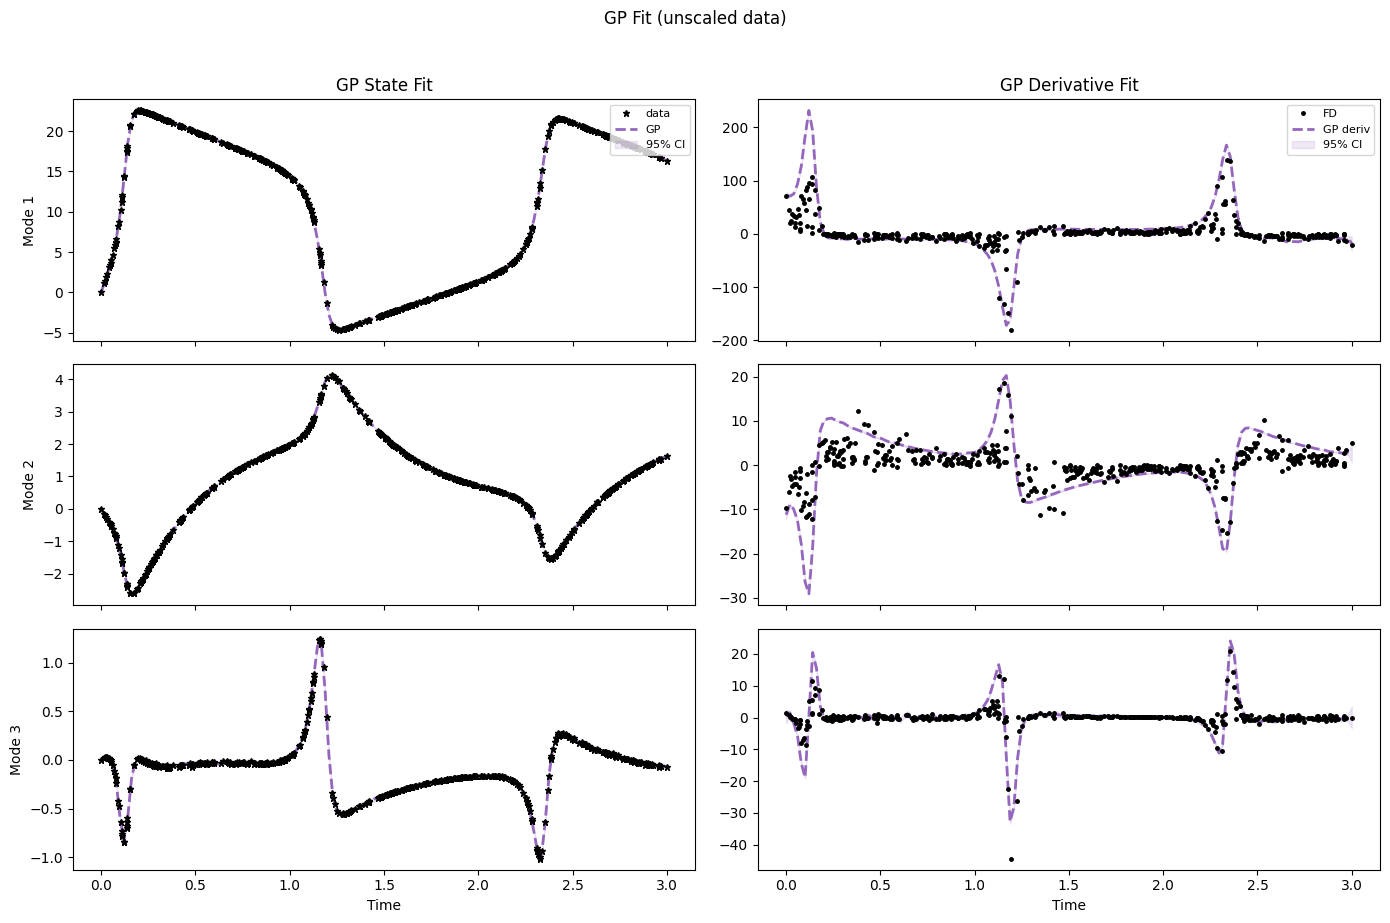

In [10]:
# Visualize GP fit quality (states and derivatives)
# Note: GP models were fitted on training_data (scaled if USE_SCALED_DATA)
_plot_t0 = time.time()
fig, axes = plot_gp_fit(
    gp_models=gp_models,
    snapshots_compressed=training_data,
    time_sampled=time_sampled,
    time_eval=time_domain_eval_training,
    lengthscales=Ls,
    variances=Vs,
    plot_derivatives=True,
)
plt.suptitle(f"GP Fit ({'scaled' if USE_SCALED_DATA else 'unscaled'} data)", y=1.02)
plt.show()
total_plot_time += time.time() - _plot_t0

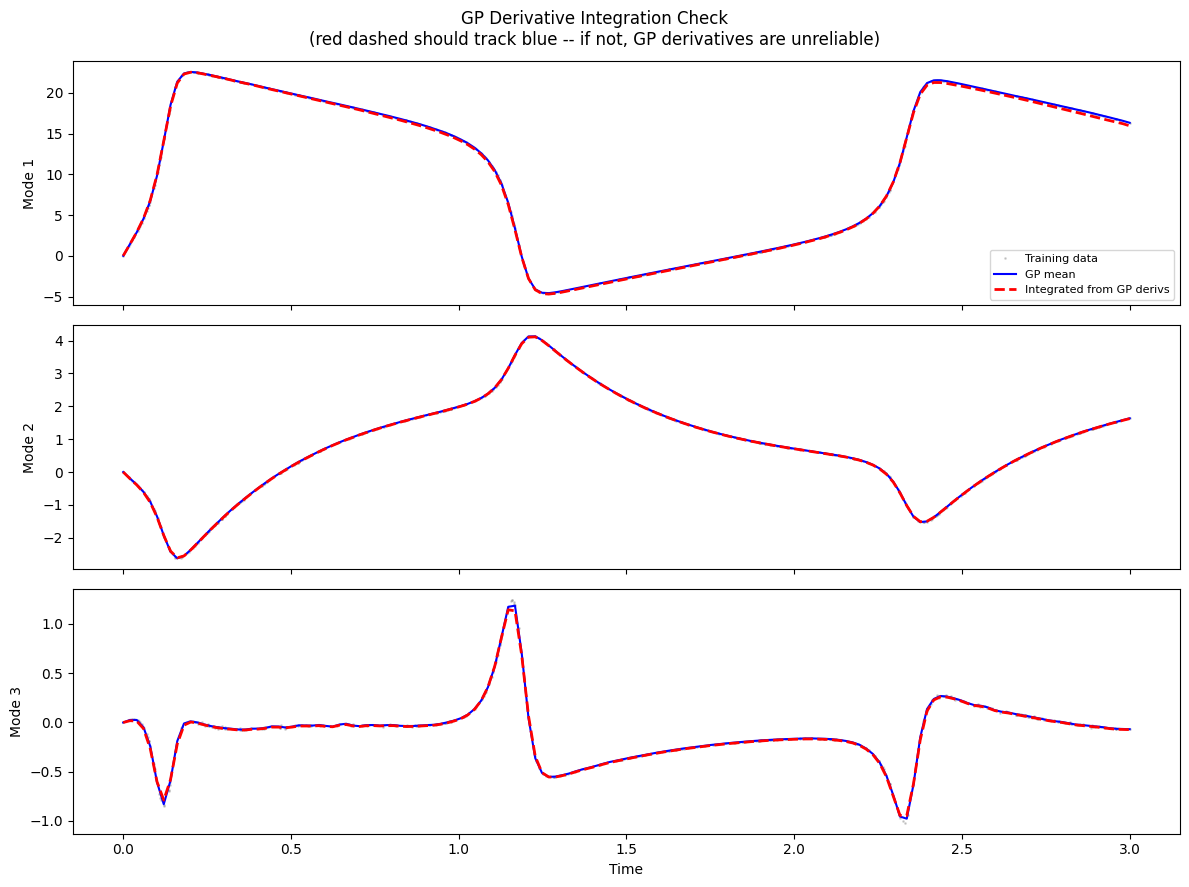

  Mode 1: relative L2 integration error = 0.0116
  Mode 2: relative L2 integration error = 0.0046
  Mode 3: relative L2 integration error = 0.0312


In [11]:
# Sanity check: integrate GP derivatives to see if they reconstruct the trajectory.
# If the integrated trajectory diverges from the data, the GP derivatives are unreliable
# and downstream Bayesian inference will struggle regardless of hyperparameters.
from scipy.integrate import cumulative_trapezoid

t_dense = time_domain_eval_training

# GP mean predictions at dense evaluation points
gp_means = np.array([
    gp_models[i].predict(t_dense[:, None], return_std=False)
    for i in range(NUM_MODES)
])

# GP derivative means at the same points
mu_z_check, _ = compute_gp_derivatives(
    Ls, Vs, time_sampled, t_dense, training_data, Ns=Ns
)

# Integrate derivatives from the initial condition: q(t) = q(0) + integral_0^t mu_z(s) ds
q_integrated = np.zeros_like(gp_means)
for i in range(NUM_MODES):
    q0 = gp_means[i, 0]  # initial condition from GP mean
    q_integrated[i, 1:] = q0 + cumulative_trapezoid(np.array(mu_z_check[i]), t_dense)
    q_integrated[i, 0] = q0

# Convert to original space for comparison if using scaled data
if USE_SCALED_DATA:
    gp_means_orig = data_scaler.inverse_transform(gp_means)
    q_integrated_orig = data_scaler.inverse_transform(q_integrated)
    data_label = "GP mean (scaled -> original)"
else:
    gp_means_orig = gp_means
    q_integrated_orig = q_integrated
    data_label = "GP mean"

fig, axes = plt.subplots(NUM_MODES, 1, figsize=(12, 3 * NUM_MODES), sharex=True)
if NUM_MODES == 1:
    axes = [axes]

for i in range(NUM_MODES):
    ax = axes[i]
    ax.plot(time_sampled, snapshots_comp_sampled[i], '.', color='gray',
            alpha=0.3, markersize=2, label='Training data')
    ax.plot(t_dense, gp_means_orig[i], 'b-', lw=1.5, label=data_label)
    ax.plot(t_dense, q_integrated_orig[i], 'r--', lw=2, label='Integrated from GP derivs')
    ax.set_ylabel(f"Mode {i+1}")
    if i == 0:
        ax.legend(fontsize=8)

axes[-1].set_xlabel("Time")
fig.suptitle("GP Derivative Integration Check\n"
             "(red dashed should track blue -- if not, GP derivatives are unreliable)",
             fontsize=12)
plt.tight_layout()
plt.show()

# Quantitative check: relative L2 error per mode
for i in range(NUM_MODES):
    l2_err = np.linalg.norm(q_integrated_orig[i] - gp_means_orig[i]) / np.linalg.norm(gp_means_orig[i])
    print(f"  Mode {i+1}: relative L2 integration error = {l2_err:.4f}")

## 3a. GP-Derivative Operator

Best operator: reg=1.00e+03, traj_err=0.5555, deriv_res=0.3930
Operator shape: (3, 14)


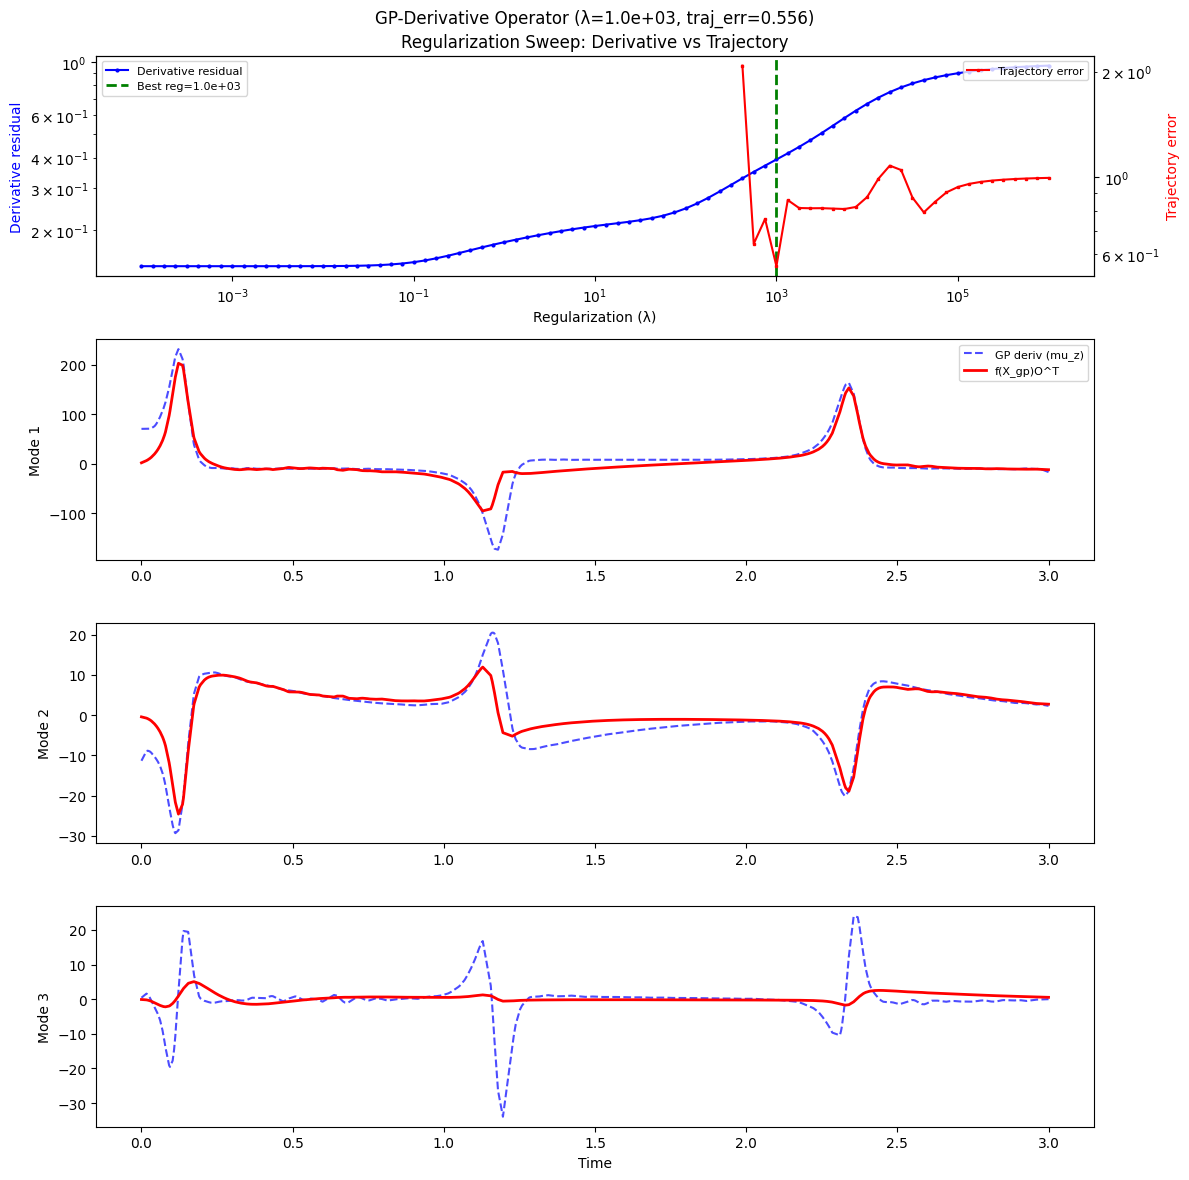

In [12]:
# Compute prior operator via least-squares on GP-smoothed states and derivatives
# Selection criterion: best TRAJECTORY fit (not derivative residual),
# since low-reg operators match derivatives well but blow up during integration.
from core.bayesian_opinf import compute_gp_derivatives

# GP states and derivatives at training times
gp_states = np.array([
    gp_models[i].predict(time_sampled[:, None], return_std=False)
    for i in range(NUM_MODES)
])

mu_z_gp, _ = compute_gp_derivatives(
    Ls, Vs, time_sampled, time_sampled, training_data, Ns=Ns
)

# Convert to original space for data matrix assembly
if USE_SCALED_DATA and data_scaler is not None:
    gp_states_orig = data_scaler.inverse_transform(gp_states)
    mu_z_orig = data_scaler.unscale_derivatives(mu_z_gp)
else:
    gp_states_orig = gp_states
    mu_z_orig = mu_z_gp

# Build data matrix from GP states
inputs_train = np.array(input_func(time_sampled)).T
D = rom.model._assemble_data_matrix(
    jnp.array(gp_states_orig), jnp.array(inputs_train.T)
)
D_np = np.array(D)
target = np.array(mu_z_orig).T  # (n_train, r)

# Truth for trajectory comparison
t_eval_reg = np.linspace(TRAINING_SPAN[0], TRAINING_SPAN[1], 150)
t_truth = np.linspace(*PREDICTION_SPAN, true_states.shape[1])
truth_at_eval = np.array([
    np.interp(t_eval_reg, t_truth, full_states_compressed[i])
    for i in range(NUM_MODES)
])
q0 = snapshots_comp_sampled[:, 0]

# Sweep regularization: select by trajectory error, not derivative residual
reg_values = np.logspace(-4, 6, 81)
best_reg, best_traj_err, best_O = None, np.inf, None
best_deriv_res = None
results_log = []

for reg in reg_values:
    O_candidate = np.linalg.solve(
        D_np.T @ D_np + reg * np.eye(D_np.shape[1]),
        D_np.T @ target
    ).T
    deriv_res = np.linalg.norm(D_np @ O_candidate.T - target) / np.linalg.norm(target)

    # Test trajectory stability
    rom.model._extract_operators(np.array(O_candidate))
    try:
        rom.model.predict(state0=q0, t=t_eval_reg, input_func=input_func, method=IVP_METHOD)
        res = rom.model.predict_result_
        if res.success and res.t.shape[0] == len(t_eval_reg):
            traj_err = np.linalg.norm(res.y - truth_at_eval) / np.linalg.norm(truth_at_eval)
        else:
            traj_err = np.inf
    except Exception:
        traj_err = np.inf

    results_log.append((reg, deriv_res, traj_err))
    if traj_err < best_traj_err:
        best_traj_err = traj_err
        best_reg = reg
        best_O = O_candidate.copy()
        best_deriv_res = deriv_res

prior_operator = best_O
print(f"Best operator: reg={best_reg:.2e}, traj_err={best_traj_err:.4f}, deriv_res={best_deriv_res:.4f}")
print(f"Operator shape: {prior_operator.shape}")

# Plot: derivative fit + reg sweep
fig, axes = plt.subplots(NUM_MODES + 1, 1, figsize=(12, 3 * (NUM_MODES + 1)), sharex=False)

# Top panel: regularization sweep
regs, d_res, t_err = zip(*results_log)
ax0 = axes[0]
ax0.loglog(regs, d_res, 'b-o', markersize=2, label='Derivative residual')
ax0_r = ax0.twinx()
t_err_plot = [e if e < 10 else np.nan for e in t_err]
ax0_r.semilogy(regs, t_err_plot, 'r-s', markersize=2, label='Trajectory error')
ax0.axvline(best_reg, color='green', ls='--', lw=2, label=f'Best reg={best_reg:.1e}')
ax0.set_xlabel('Regularization (λ)')
ax0.set_ylabel('Derivative residual', color='b')
ax0_r.set_ylabel('Trajectory error', color='r')
ax0.legend(loc='upper left', fontsize=8)
ax0_r.legend(loc='upper right', fontsize=8)
ax0.set_title('Regularization Sweep: Derivative vs Trajectory')

# Derivative fit for best operator
pred_derivs = (D_np @ best_O.T).T
for i in range(NUM_MODES):
    ax = axes[i + 1]
    ax.plot(time_sampled, np.array(mu_z_orig)[i], 'b--', lw=1.5, alpha=0.7, label='GP deriv (mu_z)')
    ax.plot(time_sampled, pred_derivs[i], 'r-', lw=2, label='f(X_gp)O^T')
    ax.set_ylabel(f'Mode {i+1}')
    if i == 0:
        ax.legend(fontsize=8)
axes[-1].set_xlabel('Time')
fig.suptitle(f'GP-Derivative Operator (λ={best_reg:.1e}, traj_err={best_traj_err:.3f})', fontsize=12)
plt.tight_layout()
plt.show()


Prior operator integration: success=True, steps=150/150


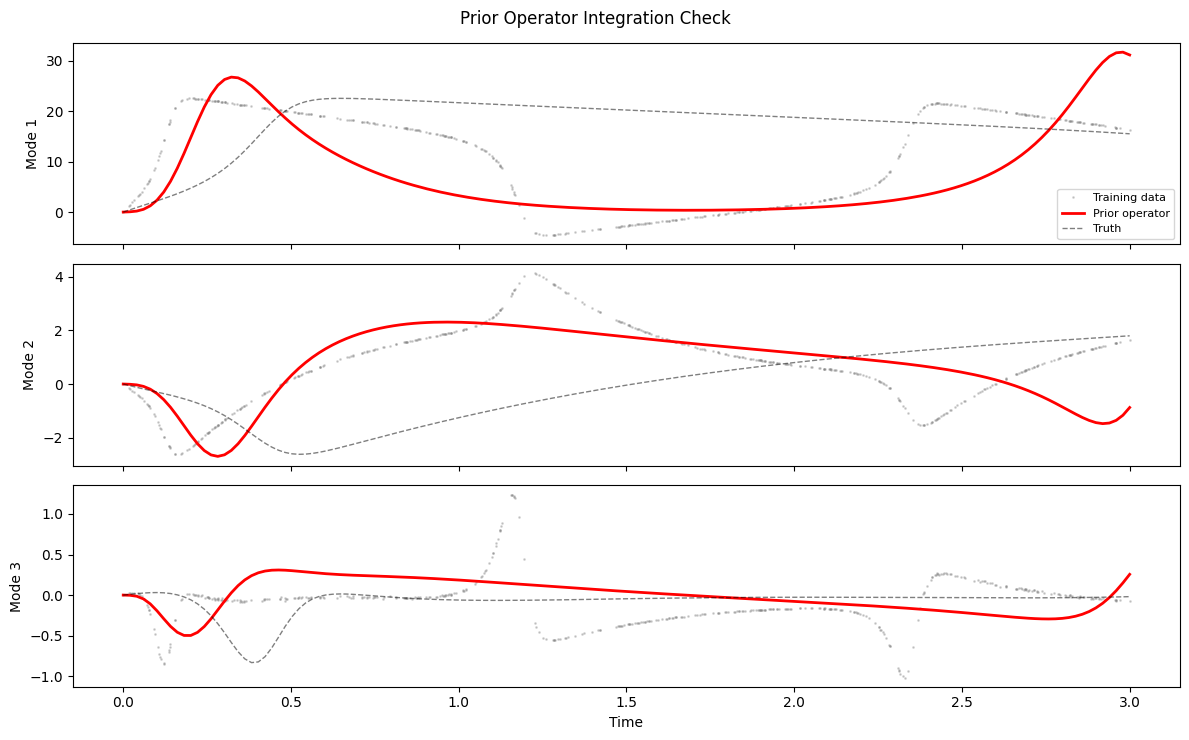

In [13]:
# Sanity check: integrate the GP-derivative operator to see if it produces good trajectories
rom.model._extract_operators(np.array(prior_operator))
q0 = snapshots_comp_sampled[:, 0]
t_eval_check = np.linspace(TRAINING_SPAN[0], TRAINING_SPAN[1], 150)

try:
    rom.model.predict(state0=q0, t=t_eval_check, input_func=input_func, method=IVP_METHOD)
    result_check = rom.model.predict_result_
    print(f"Prior operator integration: success={result_check.success}, "
          f"steps={result_check.t.shape[0]}/{len(t_eval_check)}")

    if result_check.success:
        fig, axes = plt.subplots(NUM_MODES, 1, figsize=(12, 2.5 * NUM_MODES), sharex=True)
        if NUM_MODES == 1: axes = [axes]
        for i in range(NUM_MODES):
            axes[i].plot(time_sampled, snapshots_comp_sampled[i], '.', color='gray', alpha=0.3, markersize=2, label='Training data')
            axes[i].plot(t_eval_check, result_check.y[i], 'r-', lw=2, label='Prior operator')
            axes[i].plot(time_domain_eval_training, full_states_compressed[i, :len(time_domain_eval_training)] if len(full_states_compressed[i]) >= len(time_domain_eval_training) else np.interp(time_domain_eval_training, np.linspace(*PREDICTION_SPAN, len(full_states_compressed[i])), full_states_compressed[i]), 'k--', lw=1, alpha=0.5, label='Truth')
            axes[i].set_ylabel(f'Mode {i+1}')
            if i == 0: axes[i].legend(fontsize=8)
        axes[-1].set_xlabel('Time')
        fig.suptitle('Prior Operator Integration Check', fontsize=12)
        plt.tight_layout()
        plt.show()
    else:
        print(f"  Failed at t={result_check.t[-1]:.4f}: {result_check.message}")
except Exception as e:
    print(f"Prior operator integration CRASHED: {e}")


## 4. Bayesian Inference

In [14]:
# Build evaluation time grid (densified via GP if NUM_EVAL_POINTS is set)
if NUM_EVAL_POINTS is not None:
    time_eval = np.linspace(time_sampled[0], time_sampled[-1], NUM_EVAL_POINTS)
    print(f"GP densification: evaluating ODE constraints at {NUM_EVAL_POINTS} points "
          f"(vs {len(time_sampled)} training samples)")
else:
    time_eval = time_sampled
    print(f"No densification: evaluating at {len(time_sampled)} training times")

# Precompute GP mean predictions at evaluation points
Xs_means = np.array([
    gp_models[i].predict(time_eval[:, None], return_std=False)
    for i in range(NUM_MODES)
])
inputs_eval = np.array(input_func(time_eval)).T

# Build Bayesian model using shared factory function
bayesian_opinf_model = build_bayesian_opinf_model(
    prior_operator=prior_operator,
    rom=rom,
    Ls_means=Ls,
    Vs_means=Vs,
    time_domain_sampled=time_sampled,
    snapshots=training_data,
    Xs_means=Xs_means,
    Ns_means=Ns,
    inputs_eval=inputs_eval,
    data_scaler=data_scaler if USE_SCALED_DATA else None,
    relative_gamma=True,
    relative_gamma2=RELATIVE_GAMMA2,
    reparam="shifted",
    svi_O_mean=jnp.array(prior_operator),
    svi_O_std=jnp.ones_like(jnp.array(prior_operator)) * GAMMA,
    min_absolute_std=1e-2,
    min_relative_std=0.0,
)
print("Bayesian model built")

No densification: evaluating at 450 training times
Bayesian model built


Running SVI (gamma=0.1, gamma2=0.1)...


100%|██████████| 100000/100000 [09:46<00:00, 170.58it/s, init loss: 696046.5625, avg. loss [95001-100000]: 497196.5000]


✅ SVI complete! Final loss: 494613.8125
   Sample keys: ['O', 'O_standardized', 'X0_0', 'X0_1', 'X0_2', 'ode_constraint0_0', 'ode_constraint0_1', 'ode_constraint0_2']
SVI operator extracted from key 'O', shape: (3, 14)


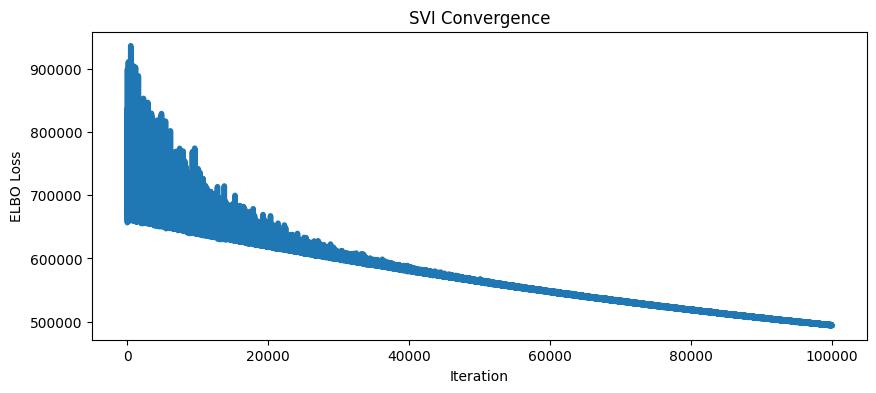

In [15]:
# Run SVI
from functools import partial
from numpyro.infer import init_to_value

if RUN_SVI:
    # Construct guide with rank and initialization at GP-derivative operator
    guide_with_kwargs = partial(
        GUIDE,
        init_loc_fn=init_to_value(values={"O_standardized": jnp.zeros_like(jnp.array(prior_operator))}),
    )

    svi_result = run_svi(
        model=bayesian_opinf_model,
        rng_key=rng_key,
        time_eval=time_eval,
        gamma=GAMMA,
        gamma2=GAMMA2,
        num_steps=100000,
        learning_rate=1e-4,
        verbose=VERBOSE,
        guide=guide_with_kwargs,
    )
    samples = svi_result.samples

    # Extract operator for diagnostics
    O_key = 'O' if 'O' in samples else next((k for k in samples.keys() if 'O' in k and 'ode' not in k.lower()), None)
    if O_key:
        svi_O = samples[O_key]
        svi_O_init = svi_O.mean(axis=0) if svi_O.ndim > 2 else svi_O[0]
        print(f"SVI operator extracted from key '{O_key}', shape: {svi_O_init.shape}")
    else:
        svi_O_init = None
        print("Warning: Could not extract O from SVI samples")

    # Plot loss
    plt.figure(figsize=(10, 4))
    plt.plot(svi_result.losses, lw=4)
    plt.xlabel('Iteration')
    plt.ylabel('ELBO Loss')
    plt.title('SVI Convergence')
    plt.show()

### 4a. SVI Results

In [16]:
import importlib, fitz_plotter
importlib.reload(fitz_plotter)
from fitz_plotter import FitzPlotter

def _evaluate_and_plot(stage_samples, stage_name):
    """Generate predictions and plots for a given inference stage."""
    Os_stage, Xs_stage, rom_solves_stage = generate_rom_predictions(
        samples=stage_samples, rom=rom,
        snapshots_compressed=snapshots_comp_sampled,
        time_eval=time_domain_eval_prediction,
        num_modes=NUM_MODES, num_pulls=200,
        input_func=input_func,
        data_scaler=data_scaler if USE_SCALED_DATA else None,
        ivp_method=IVP_METHOD,
    )
    print(f"[{stage_name}] Operator samples: {len(Os_stage)}, "
          f"Stable solves: {len(rom_solves_stage)}")

    # Operator posterior summary
    O_mean_stage = Os_stage.mean(axis=0)
    O_std_stage = Os_stage.std(axis=0)
    print(f"\n{stage_name} Posterior mean (first row): {O_mean_stage[0, :5]}")
    print(f"{stage_name} Posterior std  (first row): {O_std_stage[0, :5]}")

    # Get latent state samples and inverse-transform if scaled
    latent_state_samples = []
    for i in range(NUM_MODES):
        key_multi = f'X0_{i}'
        key_legacy = f'X{i}'
        key = key_multi if key_multi in stage_samples else key_legacy
        if key in stage_samples:
            Xi = stage_samples[key]
            if USE_SCALED_DATA and data_scaler is not None:
                Xi = np.array(Xi) * data_scaler.stds_[i, 0] + data_scaler.means_[i, 0]
            latent_state_samples.append(Xi)
        else:
            latent_state_samples.append(np.tile(snapshots_comp_sampled[i], (len(Os_stage), 1)))

    # State reconstruction using FitzPlotter
    plotter_stage = FitzPlotter(
        numPODmodes=NUM_MODES,
        time_domain_training=time_sampled,
        time_domain_prediction=time_domain_full,
        time_domain_eval_training=time_domain_eval_training,
        time_domain_eval_prediction=time_domain_eval_prediction,
        snapshots_training=snapshots_comp_sampled,
        snapshots_prediction=full_states_compressed,
    )

    try:
        # Single-column view
        fig_rom = plotter_stage.operator_plot(
            q0=snapshots_comp_sampled[:, 0],
            operator_samples=Os_stage,
            latent_state_samples=latent_state_samples,
            rom=rom,
            input_func=input_func,
            figsize=(10, 2.5 * NUM_MODES),
            max_num_samples=200,
            plot_single=True,
            training_span=TRAINING_SPAN,
            ivp_method=IVP_METHOD,
        )
        plt.suptitle(f'ROM Predictions ({stage_name})', fontsize=14)
        plt.show()
    except Exception as e:
        fig_rom = None
        print(f"Failed to generate a plot due to: {e}")

    # Full-order prediction error
    rom_solves_pred = []
    q0 = snapshots_comp_sampled[:, 0]
    for O in Os_stage:
        rom.model._extract_operators(O)
        try:
            rom.model.predict(state0=q0, t=time_domain_eval_prediction, input_func=input_func, method=IVP_METHOD)
            if rom.model.predict_result_.y.shape[1] == len(time_domain_eval_prediction):
                rom_solves_pred.append(rom.model.predict_result_.y)
        except Exception:
            pass
    rom_solves_pred = np.array(rom_solves_pred)
    print(f"Stable ROM solves on prediction domain: {len(rom_solves_pred)}")

    if len(rom_solves_pred) > 0:
        fig, axes = plot_full_order_error(
            rom_solves=rom_solves_pred,
            basis=basis,
            true_states=true_states,
            time_domain_full=time_domain_full,
            time_domain_eval=time_domain_eval_prediction,
            training_span=TRAINING_SPAN,
            error_type='relative',
            figsize=(12, 10),
        )
        plt.suptitle(f'Full-Order Error ({stage_name})', fontsize=14)
        fig_error = fig
        plt.show()
    else:
        fig_error = None

    return Os_stage, rom_solves_stage, fig_rom, fig_error

[SVI] Operator samples: 200, Stable solves: 0

SVI Posterior mean (first row): [ 3.1802619   3.9749517   1.2105281  -2.8002653  -0.16508804]
SVI Posterior std  (first row): [0.01050227 0.00245782 0.00908087 0.01146097 0.00010566]
(200, 3, 14) (1000, 3, 450)
Bad solve within training domain, skipping (3, 73)
Bad solve within training domain, skipping (3, 74)
Bad solve within training domain, skipping (3, 78)
Bad solve within training domain, skipping (3, 77)
Bad solve within training domain, skipping (3, 75)
Bad solve within training domain, skipping (3, 77)
Bad solve within training domain, skipping (3, 74)
Bad solve within training domain, skipping (3, 79)
Bad solve within training domain, skipping (3, 76)
Bad solve within training domain, skipping (3, 79)
Bad solve within training domain, skipping (3, 78)
Bad solve within training domain, skipping (3, 75)
Bad solve within training domain, skipping (3, 76)
Bad solve within training domain, skipping (3, 76)
Bad solve within training do

<Figure size 640x480 with 0 Axes>

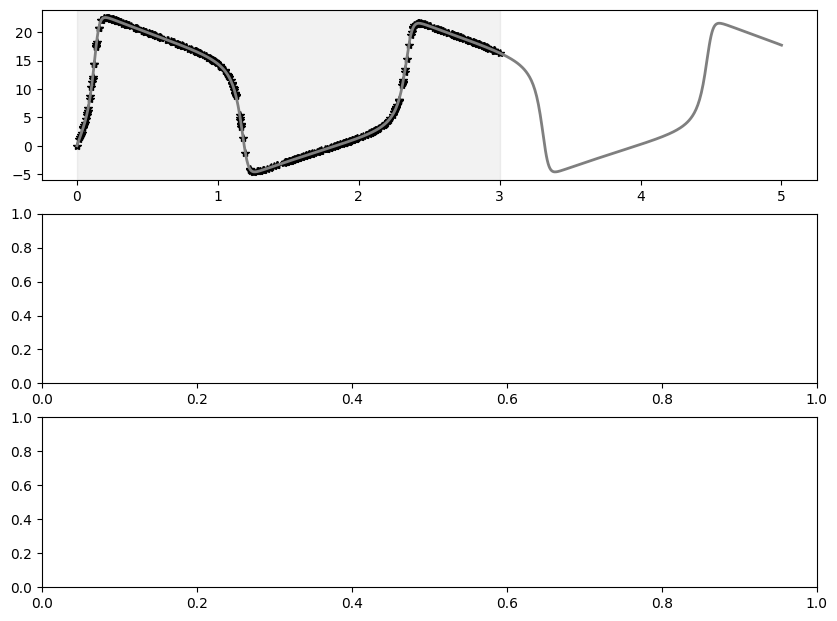

In [17]:
# === SVI Results ===
svi_start_time = time.time()

if RUN_SVI:
    svi_Os, svi_rom_solves, svi_fig_rom, svi_fig_err = _evaluate_and_plot(svi_result.samples, "SVI")
    if SAVE_PAPER_FIGURES:
        save_paper_figure(svi_fig_rom, f"fn_{PAPER_SCENARIO}_gp_bayes", PAPER_FIGURES_DIR)
        if svi_fig_err is not None:
            save_paper_figure(svi_fig_err, f"fn_{PAPER_SCENARIO}_gp_bayes_error", PAPER_FIGURES_DIR)

total_plot_time += time.time() - svi_start_time

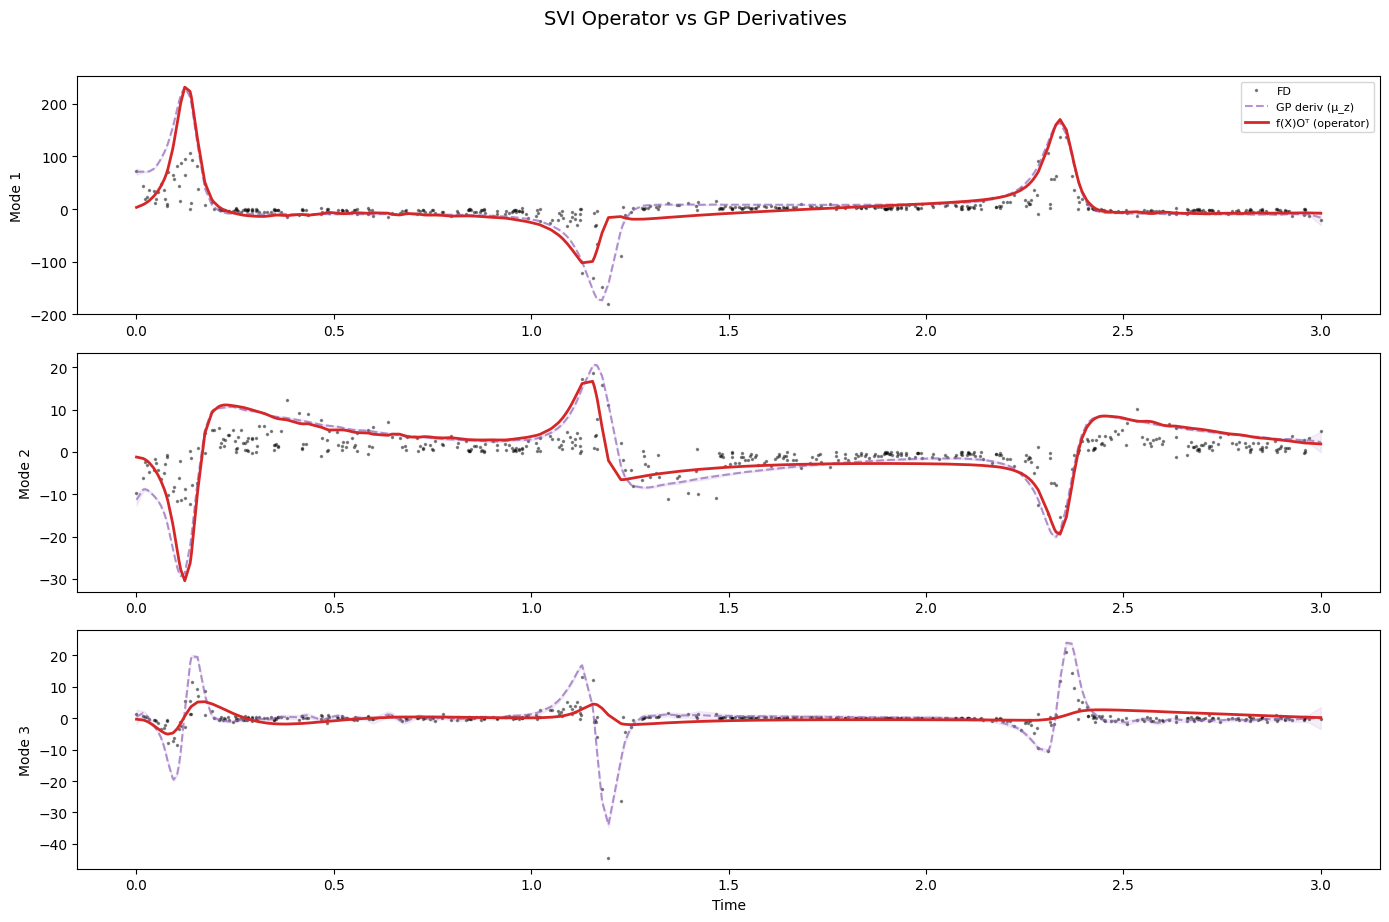

In [18]:
# Operator derivative fit diagnostic (SVI)
try:
    _O_mean = svi_Os.mean(axis=0)
    plot_operator_derivative_fit(
        operator=_O_mean,
        rom=rom,
        Xs_means=Xs_means,
        time_eval=time_eval,
        Ls=Ls, Vs=Vs,
        time_train=time_sampled,
        snapshots=training_data,
        Ns=Ns,
        inputs_eval=inputs_eval,
        data_scaler=data_scaler if USE_SCALED_DATA else None,
        title="SVI Operator vs GP Derivatives",
    )
    plt.show()
except Exception as e:
    print(f"SVI derivative fit plot failed: {e}")

In [19]:
# End time of the algorithm

end_time = time.time()
algo_time = end_time - start_time - total_plot_time

print(f"Total wall time: {end_time - start_time:.1f}s")
print(f"Plot time excluded: {total_plot_time:.1f}s")
print(f"Algorithm runtime: {algo_time:.1f}s ({algo_time/60:.1f}min)")

Total wall time: 640.7s
Plot time excluded: 40.6s
Algorithm runtime: 600.1s (10.0min)


## 5. Summary

In [20]:
# Summary
print("=" * 50)
print("EXPERIMENT SUMMARY: FitzHugh-Nagumo (GP-Bayesian)")
print("=" * 50)
print(f"Operators: {OPERATORS}")
print(f"Modes: {NUM_MODES}")
print(f"Training span: [{TRAINING_SPAN[0]}, {TRAINING_SPAN[1]}]")
print(f"Prediction span: [{PREDICTION_SPAN[0]}, {PREDICTION_SPAN[1]}]")
print(f"Scaling: {'enabled' if USE_SCALED_DATA else 'disabled'}")
print(f"GP-derivative operator: reg = {best_reg:.1e}, relative residual = {best_residual:.4f}")
print(f"Gamma (operator): {GAMMA}")
print(f"Gamma2 (ODE): {GAMMA2}")
print(f"Guide: {GUIDE.__name__}")
print(f"SVI rank: {SVI_RANK}")
if RUN_SVI:
    print(f"\nSVI: {len(svi_Os)} operator samples, {len(svi_rom_solves)} stable solves")

EXPERIMENT SUMMARY: FitzHugh-Nagumo (GP-Bayesian)
Operators: cAHBN
Modes: 3
Training span: [0, 3.0]
Prediction span: [0, 5.0]
Scaling: disabled


NameError: name 'best_residual' is not defined

## 6. Bayesian Model Diagnostics

Run post-inference diagnostics to check for common pitfalls:
- **Posterior correlation** -- highly correlated parameters suggest redundancy or non-identifiability
- **Effective sample size (ESS)** -- low ESS means samples are highly autocorrelated
- **Prior-posterior overlap** -- checks if data is actually informing the posterior

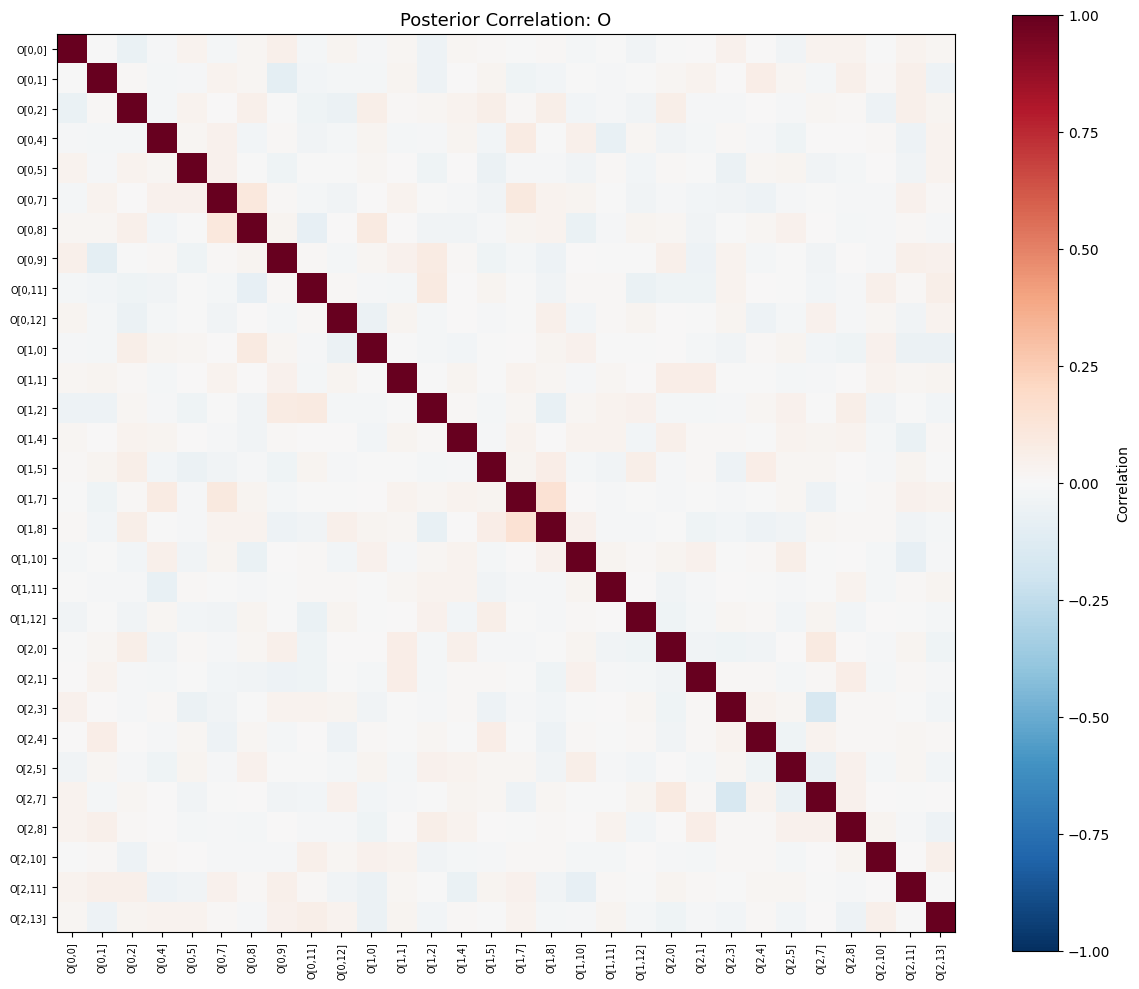

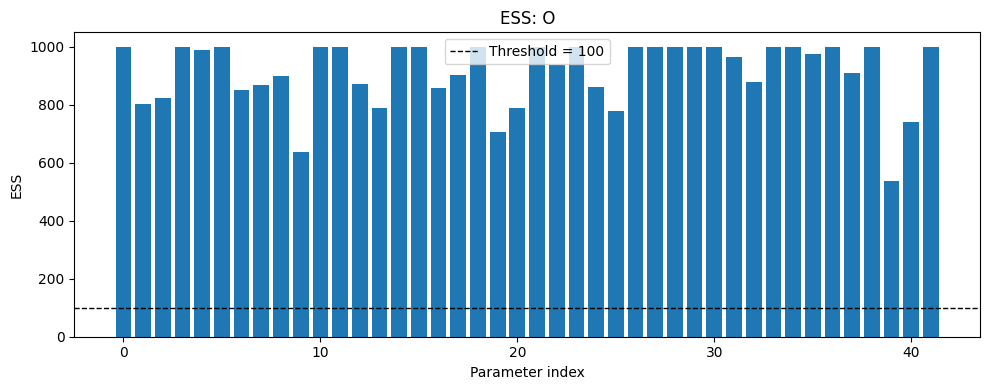

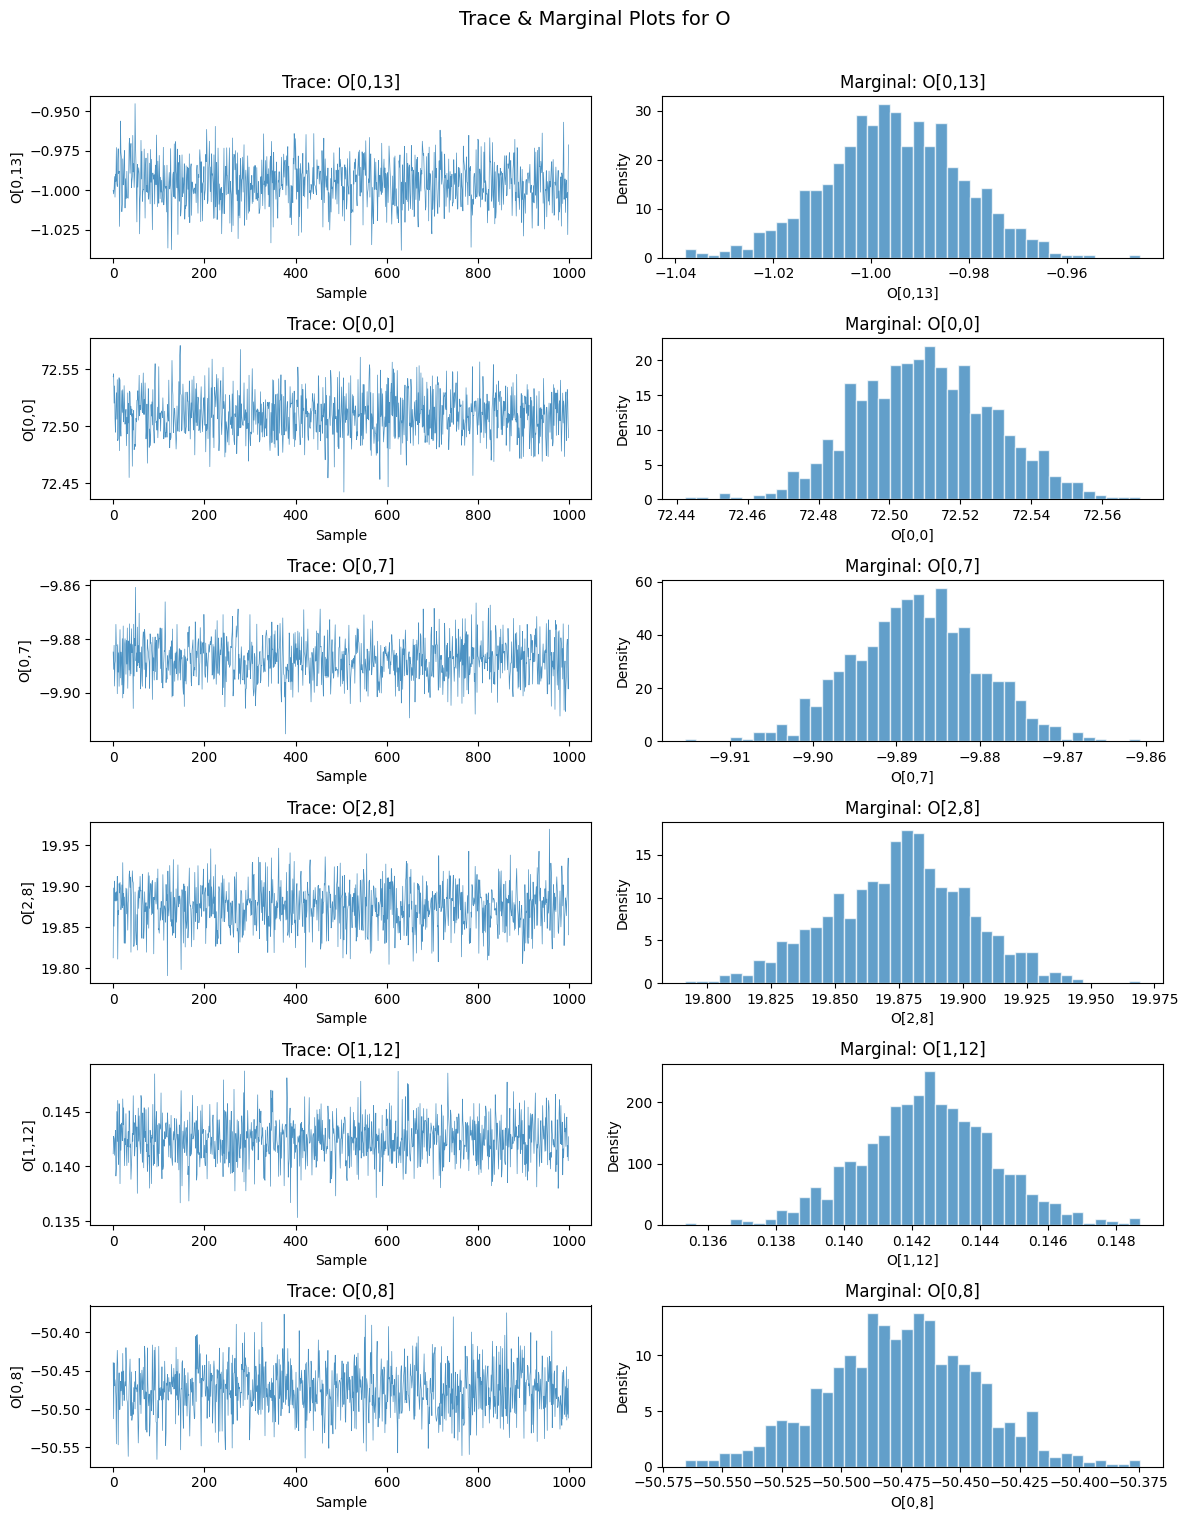

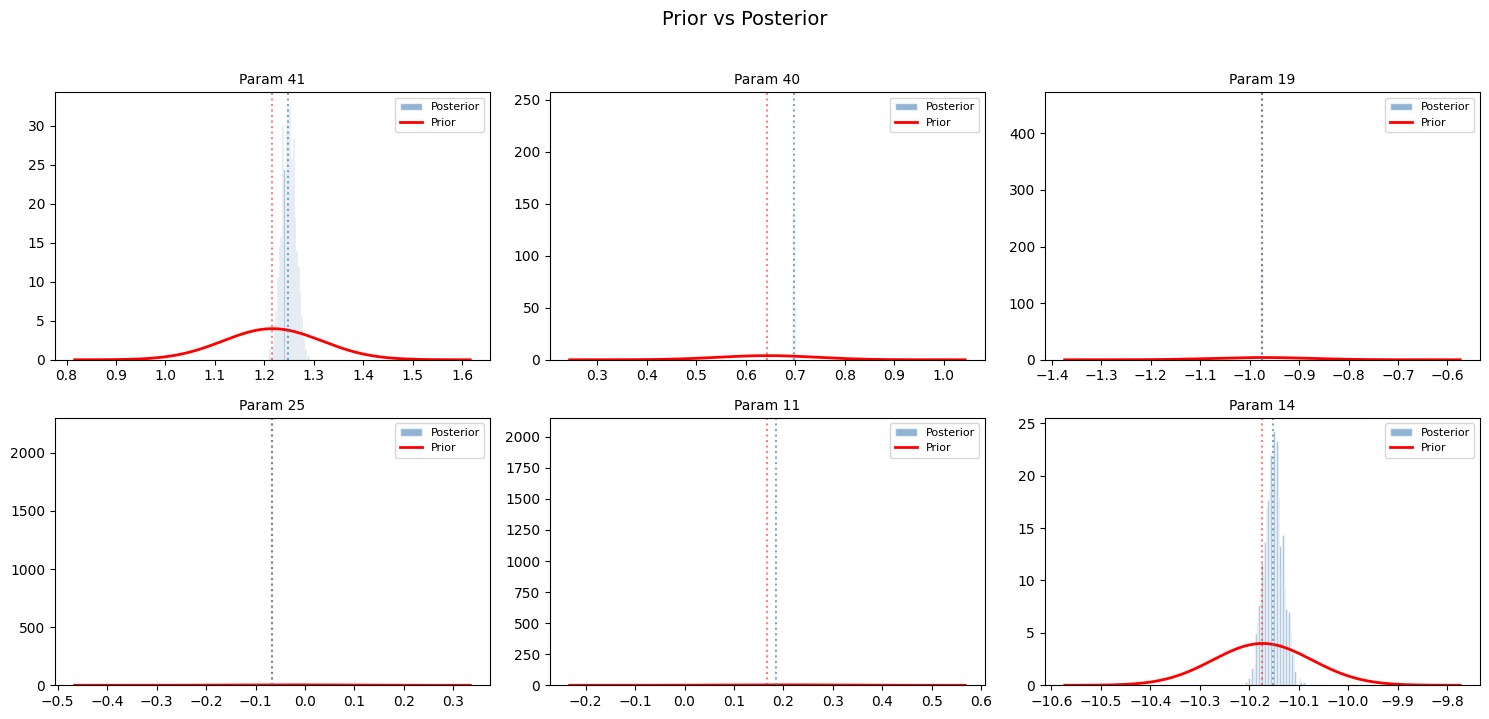

  BAYESIAN MODEL DIAGNOSTIC REPORT

--- Posterior Correlation ---
  No high correlations detected (|r| > 0.9).

--- Effective Sample Size (ESS) ---
  Min ESS:  536.1
  Mean ESS: 913.6
  Max ESS:  1000.0

--- Prior-Posterior Overlap ---
  O[1,2]: overlap = 24.82% [OK]
  O[0,9]: overlap = 0.00% [CHECK]
  O[0,5]: overlap = 6.44% [CHECK]
  O[0,0]: overlap = 9.33% [CHECK]
  O[2,11]: overlap = 3.22% [CHECK]

--- Summary Warnings ---
  1. Prior-posterior overlap for O[0,9] is 0% — prior may be misspecified (too narrow or wrong location).
  2. Prior-posterior overlap for O[2,11] is 3% — prior may be misspecified (too narrow or wrong location).



In [ ]:
# Use SVI samples for diagnostics
diag_samples = svi_result.samples

# Run full diagnostic suite
diag_report = run_diagnostics(
    samples=diag_samples,
    param_name="O",
    prior_mean=prior_operator,
    prior_std=GAMMA,
    mcmc_result=None,
    samples_by_chain=None,
    correlation_threshold=0.9,
    ess_threshold=100,
    verbose=VERBOSE,
    plot=True,
)

  STABILITY DIAGNOSTIC REPORT

--- Operator Stability ---
  Prior operator:     UNSTABLE
  Posterior MAP/mean: UNSTABLE

--- ELBO Convergence ---
  Status: converged  (final slope = -1.88e-02)

--- Prior → Posterior Shift ---
  Mode 0: ‖ΔO‖ = 1.2827
  Mode 1: ‖ΔO‖ = 0.1185
  Mode 2: ‖ΔO‖ = 1.2518
  Per-block relative shift (‖Δblock‖/‖prior_block‖):
    c: 0.0029
    A: 0.0021
    H: 0.0216
    B: 0.0482
    N: 0.1068

--- Linear Operator (A) Eigenvalues ---
  Prior  max Re(λ): -0.250579  (stable)
  Post.  max Re(λ): -0.207986  (stable)

--- Perturbation Sensitivity ---
  Perturb c: ░░░░░░░░░░░░░░░░░░░░ 0% stable
  Perturb A: ░░░░░░░░░░░░░░░░░░░░ 0% stable
  Perturb H: ░░░░░░░░░░░░░░░░░░░░ 0% stable
  Perturb B: ░░░░░░░░░░░░░░░░░░░░ 0% stable
  Perturb N: ░░░░░░░░░░░░░░░░░░░░ 0% stable

--- ⚠  Warnings ---
  • Prior operator is UNSTABLE — posterior has nowhere safe to start.
  • Posterior MAP/mean is UNSTABLE — SVI may not have converged or GAMMA/GAMMA2 need tuning.
  • Blocks ['c', 'A'

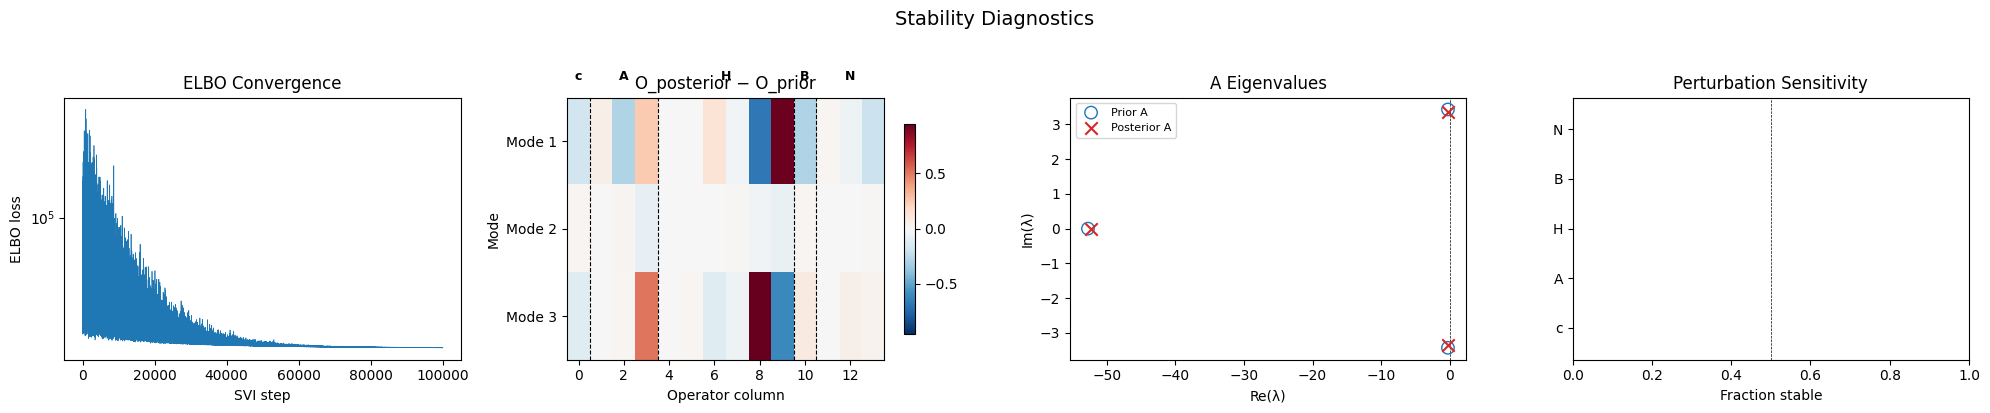

In [ ]:
# Stability diagnostics: MAP stability, ELBO convergence, eigenvalues, perturbation sensitivity
posterior_O = svi_Os.mean(axis=0)
stability_report = diagnose_stability(
    posterior_operator=posterior_O,
    prior_operator=prior_operator,
    rom=rom,
    snapshots_compressed=snapshots_comp_sampled,
    time_eval=time_domain_eval_prediction,
    operators=OPERATORS,
    input_func=input_func,
    input_dim=1,
    losses=svi_result.losses if RUN_SVI else None,
)